# Iterative Tweet Generator

This notebook demonstrates iterative generation, evaluation, and optimization of tweets using `langgraph` and `langchain` LLMs.


In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal,Annotated
from langchain_core.messages import SystemMessage,HumanMessage
from dotenv import load_dotenv
from pydantic import BaseModel,Field
load_dotenv()


True

In [4]:
generator_llm= ChatOpenAI(model='gpt-4o')
evaluator_llm=ChatOpenAI(model='gpt-4o-mini')
optimizer_llm=ChatOpenAI(model='gpt-4o')

In [5]:
class TweetState(TypedDict):
    topic:str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration: int
    max_iteration: int




In [8]:
def generate_tweet(state:TweetState):
    prompt= f"generate an original tweet on the topic: {state['topic']}. Rules:Do not use question answer format, keep maximum characters 280, use observational humor, irony, cultural references, think in meme logic, punchlines or relatable takes. Use simple day to day English."
    response=generator_llm.invoke(prompt).content
    return {"tweet":response}

In [9]:
from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","needs_improvement"]=Field(description="Final evaluation")
    feedback:str =Field(description="Feedback for the tweet")


In [10]:
structured_evaluator_llm=evaluator_llm.with_structured_output(TweetEvaluation)

In [20]:
def evaluate_tweet(state:TweetState):
    prompt=f"""Use the criteria below to evaluate the tweet: {state["tweet"]} on  \n 1.Originality 2.Humor 3.Punchlines 4.Virality Potential 5.Format, Auto reject if: it is written in question--answer format, it exceeds 280 characters, it reads like a traditional setup-punchline joke, do not end with generic, throwaway or deflating lines that weaken the humor. Respond only in strucutred format: 
    evaluation:'approved' or 'needs improvement
    feedback:one paragraph explaining the strengths and weaknesses'"""
    response=structured_evaluator_llm.invoke(prompt)
    return {"evaluation":response.evaluation,"feedback":response.feedback}

In [21]:
def optimize_tweet(state:TweetState):
    prompt=f"""You improve tweets based on virality and humor based on given feedback
    \n {state["feedback"]} \n topic: {state["topic"]}, tweet: {state["tweet"]}. Rewrite it as short viral worthy tweet under 280 characters"""
    response=optimizer_llm.invoke(prompt).content
    iteration=state['iteration']+1
    return {"tweet":response,"iteration":iteration}

In [22]:
def route_evaluation(state:TweetState):

    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'


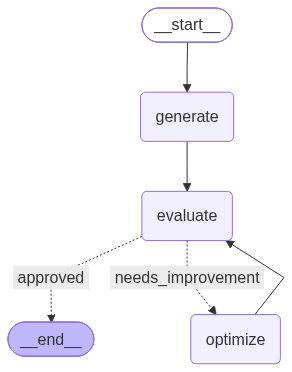

In [23]:
graph=StateGraph(TweetState)

graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimize',optimize_tweet)





graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')

graph.add_conditional_edges('evaluate',route_evaluation, {'approved':END, 'needs_improvement':'optimize'})


graph.add_edge('optimize','evaluate')


workflow=graph.compile()
workflow


In [27]:
initial_state={
    "topic":"Dolphins",
    "iteration": 1,
    "max_iteration":5
}

workflow.invoke(initial_state)

{'topic': 'Dolphins',
 'tweet': '"Dolphins: the ocean\'s cheerleaders who somehow manage to be both the smartest creatures in the sea and proud members of the \'I have a permanent smile but zero sense of an indoor voice\' club. Seriously, they\'re the aquatic version of that overly enthusiastic friend who\'s a blast at parties but you secretly suspect has a secret podcast about fish conspiracies. 🐬🎧🌊 #DolphinLogic"',
 'evaluation': 'approved',
 'feedback': "This tweet showcases strong originality with a unique comparison of dolphins to a lively friend, which adds a humorous twist. The humor is effectively conveyed through the playful language and imaginative metaphors, such as 'ocean's cheerleaders' and 'secret podcast about fish conspiracies.' The punchlines are cleverly embedded, making it engaging without adhering to a traditional setup-punchline format. The use of emojis enhances the visual appeal and adds to the fun tone, increasing its virality potential. Overall, it maintains an